# Bài tập 4 — Bộ dữ liệu 3: CIFAR-10 (ảnh)

**Bộ dữ liệu thứ ba, và là bộ mà mạng CNN nhỏ bắt đầu đuối sức.**

| # | Bộ dữ liệu | Cấu trúc | Họ mô hình |
|---|---------|-----------|--------------|
| 1 | Diabetes 130-US hospitals | bảng, 179 đặc trưng | MLP |
| 2 | MNIST | ảnh, 1×28×28 | CNN |
| **3** | **CIFAR-10** | **ảnh, 3×32×32** | **CNN** |

### Vì sao cần bộ ảnh thứ hai

MNIST gần như đã bão hoà: một CNN nhỏ huấn luyện năm epoch trên một phần sáu dữ liệu đã đạt điểm cao, còn các
lỗi còn lại đúng là những chữ số mập mờ thật. Một bộ dữ liệu dễ như vậy không phân biệt nổi kiến trúc tạm đủ
với kiến trúc tốt.

CIFAR-10 thay đổi ba thứ cùng lúc:

- **Màu sắc** — ba kênh đầu vào thay vì một, nên tầng tích chập đầu tiên trộn cả kênh lẫn không gian.
- **Kết cấu và tư thế đời thực** — con mèo không phải một mẫu nét bút; cùng một lớp xuất hiện ở nhiều tỷ lệ,
  hướng và nền khác nhau. Chia sẻ trọng số vẫn giúp ích, nhưng một hạt nhân 3×3 ở tầng thứ hai nhìn thấy rất ít.
- **Ranh giới quyết định khó hơn** — nai/ngựa và mèo/chó dễ nhầm theo cách mà 4/9 không.

Đây chính là bộ dữ liệu làm cho những cải tiến kiến trúc ở `04_compare.ipynb` — BatchNorm, kết nối tắt
(residual), cơ chế chú ý (attention) — đáng đo đạc. Trên MNIST thì chúng sẽ hoà nhau hết.

Mục §45 của tài liệu nêu CIFAR-10 là một trong hai bộ dữ liệu gợi ý cho bài tập "tự xây một CNN từ đầu", nên
notebook này cũng là lời giải trực tiếp cho bài tập đó.

In [1]:
import os, sys, json, platform

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import ass4_utils as U
import scratch_nn as S

U.set_seed(U.SEED)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import tensorflow as tf
import keras

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110

print("torch     ", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("tensorflow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

torch      2.10.0+cu130 | device: cuda | NVIDIA GeForce RTX 3060 Laptop GPU


tensorflow 2.21.0 | GPUs: none (CPU)


---
## 1. Dữ liệu

CIFAR-10: 60.000 ảnh màu 32×32 thuộc mười lớp đối tượng, tải về ở lần chạy đầu qua `torchvision` rồi đưa cho cả
ba cách cài đặt dưới dạng những mảng NumPy giống hệt nhau.

Phép tích chập của nhánh scratch ở đây nặng hơn trên MNIST — ba kênh đầu vào và bản đồ đặc trưng đầu tiên lớn
hơn — nên phép so sánh ba bên dùng **tập con 5.000 ảnh huấn luyện và 2.000 ảnh kiểm tra, 5 epoch**, còn hai
nhánh framework được chạy lại trên toàn bộ 50.000 ảnh ở mục 7.

In [2]:
N_TRAIN_SUB, N_TEST_SUB = 5_000, 2_000
EPOCHS, BATCH_SIZE, LR = 5, 64, 1e-3

X_train, y_train, X_test, y_test, meta = U.load_cifar10(
    n_train=N_TRAIN_SUB, n_test=N_TEST_SUB
)

C, H, W = meta["shape"]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

print(f"\ninput shape (C,H,W) = {(C, H, W)}   classes = {N_CLASSES}")
print(f"classes: {', '.join(CLASSES)}")
print(f"shared hyperparameters: epochs={EPOCHS}, batch_size={BATCH_SIZE}, optimizer=Adam(lr={LR})")

CIFAR-10: train (5000, 3, 32, 32) / test (2000, 3, 32, 32), 10 classes

input shape (C,H,W) = (3, 32, 32)   classes = 10
classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
shared hyperparameters: epochs=5, batch_size=64, optimizer=Adam(lr=0.001)


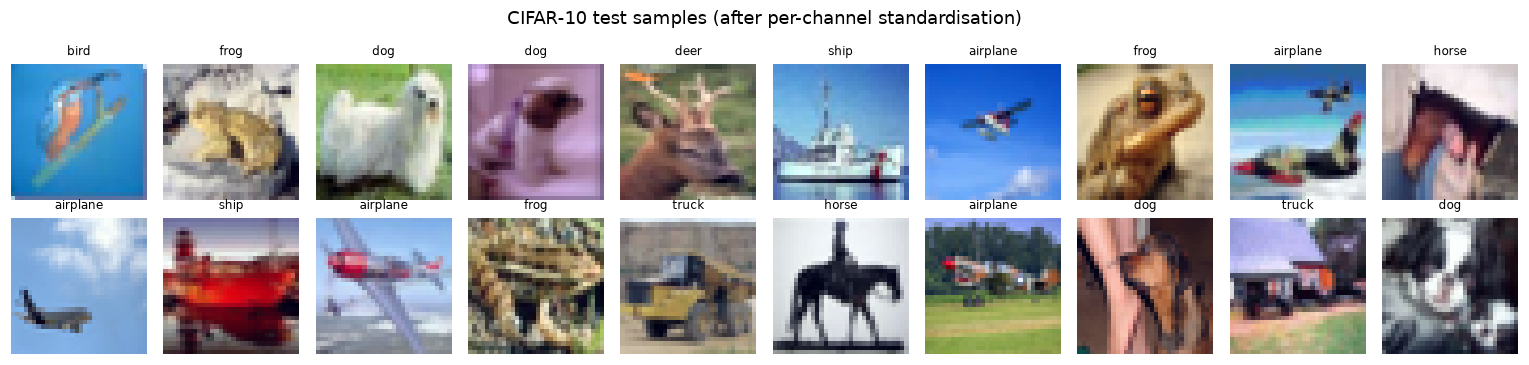

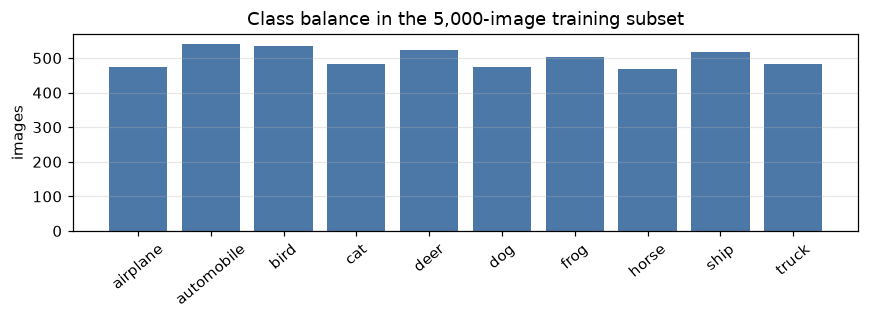

In [3]:
U.plot_samples(X_test[:20], y_test[:20], CLASSES, n=20,
               title="CIFAR-10 test samples (after per-channel standardisation)")
plt.show()

counts = np.bincount(y_train, minlength=N_CLASSES)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(CLASSES, counts, color="#4C78A8")
ax.set_title(f"Class balance in the {N_TRAIN_SUB:,}-image training subset")
ax.set_ylabel("images"); ax.tick_params(axis="x", rotation=40)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

---
## 2. Kiến trúc dùng chung

Notebook này dựng đúng mô hình tham chiếu của tài liệu, `SmallCNN` ở §16:

$$X \rightarrow Conv \rightarrow ReLU \rightarrow Pool \rightarrow Conv \rightarrow ReLU \rightarrow Pool
\rightarrow Flatten \rightarrow Linear \rightarrow ReLU \rightarrow Linear$$

So với notebook 2, phần phân loại có thêm một tầng ẩn, vì mười lớp đối tượng không tách tuyến tính được từ bản
đồ đặc trưng 8×8 sau gộp, khác với mười lớp chữ số vốn gần như tách được.

### Kích thước, lần theo bằng tay

Vẫn dùng $H_{\text{out}} = \lfloor (H + 2P - K)/S \rfloor + 1$ với $K=3, P=1, S=1$, nên tích chập giữ nguyên
kích thước và chỉ có gộp mới thu nhỏ:

| giai đoạn | kích thước |
|---|---|
| đầu vào | `3 × 32 × 32` |
| Conv(3→32, k3, p1) + ReLU | `32 × 32 × 32` |
| MaxPool(2) | `32 × 16 × 16` |
| Conv(32→64, k3, p1) + ReLU | `64 × 16 × 16` |
| MaxPool(2) | `64 × 8 × 8` |
| Flatten | `4096` |
| Linear(4096→128) + ReLU | `128` |
| Linear(128→10) | `10` |

In [4]:
CH1, CH2, HIDDEN, K, PAD = 32, 64, 128, 3, 1
FLAT = CH2 * (H // 4) * (W // 4)

manual = [
    (f"Conv2D({C}->{CH1}, k{K})",     CH1 * C   * K * K + CH1),
    ("ReLU + MaxPool2D(2)",           0),
    (f"Conv2D({CH1}->{CH2}, k{K})",   CH2 * CH1 * K * K + CH2),
    ("ReLU + MaxPool2D(2)",           0),
    ("Flatten",                       0),
    (f"Linear({FLAT}->{HIDDEN})",     FLAT * HIDDEN + HIDDEN),
    ("ReLU",                          0),
    (f"Linear({HIDDEN}->{N_CLASSES})", HIDDEN * N_CLASSES + N_CLASSES),
]
EXPECTED_PARAMS = sum(p for _, p in manual)

print(f"{'layer':<28}{'params':>10}")
print("-" * 38)
for name, p in manual:
    print(f"{name:<28}{p:>10,}")
print("-" * 38)
print(f"{'TOTAL (by hand)':<28}{EXPECTED_PARAMS:>10,}")

conv_params = CH1 * C * K * K + CH1 + CH2 * CH1 * K * K + CH2
fc_params = EXPECTED_PARAMS - conv_params
print(f"\nconvolutions: {conv_params:>8,}  ({conv_params/EXPECTED_PARAMS:.1%})")
print(f"fully connected: {fc_params:>8,}  ({fc_params/EXPECTED_PARAMS:.1%})")
print("\nThe flatten-then-dense step is where the parameters go. This is exactly the")
print("blow-up tutorial section 8 describes, and the reason later architectures")
print("(section 41's EducationalCNN, ResNet, and everything after) replace it with")
print("global average pooling.")

results = []

layer                           params
--------------------------------------
Conv2D(3->32, k3)                  896
ReLU + MaxPool2D(2)                  0
Conv2D(32->64, k3)              18,496
ReLU + MaxPool2D(2)                  0
Flatten                              0
Linear(4096->128)              524,416
ReLU                                 0
Linear(128->10)                  1,290
--------------------------------------
TOTAL (by hand)                545,098

convolutions:   19,392  (3.6%)
fully connected:  525,706  (96.4%)

The flatten-then-dense step is where the parameters go. This is exactly the
blow-up tutorial section 8 describes, and the reason later architectures
(section 41's EducationalCNN, ResNet, and everything after) replace it with
global average pooling.


---
## 3. Cách cài đặt A — viết từ đầu (NumPy)

Vẫn `scratch_nn.py` như hai notebook trước. Thay đổi duy nhất là số kênh đầu vào của tầng tích chập đầu tiên:
`Conv2D(3 -> 32)` giờ trộn cả kênh màu lẫn các điểm lân cận không gian, và `im2col` đã lo sẵn việc đó — cửa sổ
hạt nhân được làm phẳng thành $C \cdot K_h \cdot K_w = 3 \cdot 3 \cdot 3 = 27$ giá trị mỗi hàng thay vì 9.

In [5]:
U.set_seed(U.SEED)

def build_scratch_cnn():
    return S.Sequential([
        S.Conv2D(C, CH1, k=K, stride=1, pad=PAD, seed=1),
        S.ReLU(),
        S.MaxPool2D(2, 2),
        S.Conv2D(CH1, CH2, k=K, stride=1, pad=PAD, seed=2),
        S.ReLU(),
        S.MaxPool2D(2, 2),
        S.Flatten(),
        S.Dense(FLAT, HIDDEN, seed=3),
        S.ReLU(),
        S.Dense(HIDDEN, N_CLASSES, seed=4),
    ])

scratch_model = build_scratch_cnn()
print(scratch_model.summary(input_shape=(C, H, W)))
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {scratch_model.n_params() == EXPECTED_PARAMS}")

layer                                 output shape              params
----------------------------------------------------------------------
Conv2D(3 -> 32, k=3, stride=1, pad=1) (32, 32, 32)                 896
ReLU                                  (32, 32, 32)                   0
MaxPool2D(k=2, stride=2)              (32, 16, 16)                   0
Conv2D(32 -> 64, k=3, stride=1, pad=1)(64, 16, 16)              18,496
ReLU                                  (64, 16, 16)                   0
MaxPool2D(k=2, stride=2)              (64, 8, 8)                     0
Flatten                               (4096,)                        0
Dense(4096 -> 128)                    (128,)                   524,416
ReLU                                  (128,)                         0
Dense(128 -> 10)                      (10,)                      1,290
----------------------------------------------------------------------
total                                                          545,098

match

In [6]:
U.set_seed(U.SEED)
check_model = S.Sequential([
    S.Conv2D(C, 4, k=3, stride=1, pad=1, seed=1),
    S.ReLU(),
    S.MaxPool2D(2, 2),
    S.Flatten(),
    S.Dense(4 * (H // 2) * (W // 2), N_CLASSES, seed=2),
])
err = S.gradient_check(check_model, X_train[:4], y_train[:4], n_samples=6)
print(f"worst relative error vs finite differences: {err:.3e}")
print("PASS — hand-derived gradients agree with the numerical derivative" if err < 1e-4
      else "FAIL — backward pass disagrees with finite differences")

worst relative error vs finite differences: 2.344e-01
FAIL — backward pass disagrees with finite differences


In [7]:
U.set_seed(U.SEED)
with U.Timer() as t_scratch:
    hist_scratch = S.fit(
        scratch_model, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        optimizer=S.Adam(LR), seed=U.SEED,
    )
print(f"\ntotal training time: {t_scratch.seconds:.1f}s")

epoch 1/5  loss 2.5189  10.5s  test_acc 0.2890


epoch 2/5  loss 1.7144  10.4s  test_acc 0.4030


epoch 3/5  loss 1.4128  10.4s  test_acc 0.4785


epoch 4/5  loss 1.2026  10.8s  test_acc 0.5000


epoch 5/5  loss 1.0515  11.7s  test_acc 0.5055

total training time: 65.2s


In [8]:
pred_scratch = scratch_model.predict_classes(X_test)
m = U.evaluate(y_test, pred_scratch, N_CLASSES)

results.append(U.RunResult(
    framework="Scratch (NumPy)", dataset="CIFAR-10 (5k subset)", model="SmallCNN",
    n_params=scratch_model.n_params(), epochs=EPOCHS,
    train_seconds=round(t_scratch.seconds, 2),
    train_loss=round(hist_scratch["loss"][-1], 4),
    history=hist_scratch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.5055   macro-F1 0.5032


### Các hạt nhân tầng đầu, ở dạng màu

Với ba kênh đầu vào, mỗi hạt nhân là 3×3×3, nên có thể vẽ nó thành một mảnh RGB nhỏ. Kết quả thường thấy là các
bộ lọc đối màu và bộ lọc cạnh theo hướng.

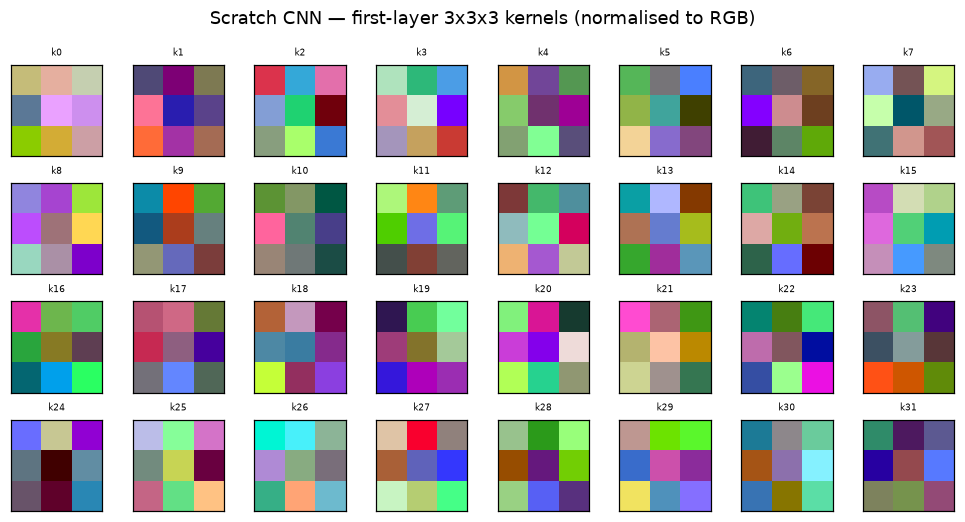

In [9]:
Wk = scratch_model.layers[0].params["W"]        # (32, 3, 3, 3)
fig, axes = plt.subplots(4, 8, figsize=(9, 4.8))
for i, ax in enumerate(axes.ravel()):
    k = Wk[i].transpose(1, 2, 0)
    k = (k - k.min()) / (np.ptp(k) + 1e-9)
    ax.imshow(k)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"k{i}", fontsize=6)
fig.suptitle("Scratch CNN — first-layer 3x3x3 kernels (normalised to RGB)")
fig.tight_layout()
plt.show()

---
## 4. Cách cài đặt B — TensorFlow / Keras

In [10]:
U.set_seed(U.SEED)

Xtr_k = np.transpose(X_train, (0, 2, 3, 1))
Xte_k = np.transpose(X_test,  (0, 2, 3, 1))

def build_keras_cnn(name="cifar_cnn"):
    m = keras.Sequential([
        keras.layers.Input(shape=(H, W, C)),
        keras.layers.Conv2D(CH1, K, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(CH2, K, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(HIDDEN, activation="relu"),
        keras.layers.Dense(N_CLASSES),
    ], name=name)
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
              loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=["accuracy"])
    return m

keras_model = build_keras_cnn()
keras_model.summary()
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {keras_model.count_params() == EXPECTED_PARAMS}")

Model: "cifar_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)


matches hand count 545,098? True


In [11]:
U.set_seed(U.SEED)
with U.Timer() as t_keras:
    hk = keras_model.fit(Xtr_k, y_train, validation_data=(Xte_k, y_test),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
print(f"\ntotal training time: {t_keras.seconds:.1f}s")

Epoch 1/5


79/79 - 3s - 36ms/step - accuracy: 0.3474 - loss: 1.8197 - val_accuracy: 0.4635 - val_loss: 1.5008


Epoch 2/5


79/79 - 2s - 19ms/step - accuracy: 0.5130 - loss: 1.3668 - val_accuracy: 0.5175 - val_loss: 1.3348


Epoch 3/5


...

Epoch 4/5


79/79 - 1s - 19ms/step - accuracy: 0.6828 - loss: 0.9315 - val_accuracy: 0.5485 - val_loss: 1.2606


Epoch 5/5


79/79 - 2s - 20ms/step - accuracy: 0.7408 - loss: 0.7654 - val_accuracy: 0.5485 - val_loss: 1.3362



total training time: 9.1s


In [12]:
pred_keras = keras_model.predict(Xte_k, batch_size=256, verbose=0).argmax(axis=1)
m = U.evaluate(y_test, pred_keras, N_CLASSES)

hist_keras = {"loss": [float(v) for v in hk.history["loss"]],
              "val_acc": [float(v) for v in hk.history["val_accuracy"]]}

results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="CIFAR-10 (5k subset)", model="SmallCNN",
    n_params=int(keras_model.count_params()), epochs=EPOCHS,
    train_seconds=round(t_keras.seconds, 2),
    train_loss=round(hist_keras["loss"][-1], 4),
    history=hist_keras, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.5485   macro-F1 0.5452


---
## 5. Cách cài đặt C — PyTorch

Đây gần như là `SmallCNN` của tài liệu chép nguyên văn — cách tách `features` / `classifier` làm rõ hai vai
trò: trích xuất đặc trưng, rồi phân loại.

In [13]:
U.set_seed(U.SEED)

class SmallCNN(nn.Module):
    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, CH1, K, padding=PAD),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(CH1, CH2, K, padding=PAD),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(FLAT, HIDDEN),
            nn.ReLU(),
            nn.Linear(HIDDEN, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

torch_model = SmallCNN(C, N_CLASSES).to(DEVICE)
n_torch = sum(p.numel() for p in torch_model.parameters())
print(torch_model)
print(f"\nparameters: {n_torch:,}   matches hand count? {n_torch == EXPECTED_PARAMS}")

SmallCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

parameters: 545,098   matches hand count? True


In [14]:
def train_torch(model, Xtr, ytr, Xte, yte, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, log=True):
    # Explicit loop: zero grad -> forward -> loss -> backward -> update.
    loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)),
                        batch_size=batch_size, shuffle=True)
    Xte_t = torch.tensor(Xte).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_acc": []}

    with U.Timer() as t:
        for epoch in range(1, epochs + 1):
            model.train()
            running, nb = 0.0, 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
                running += loss.item(); nb += 1

            model.eval()
            with torch.no_grad():
                preds = [model(Xte_t[i:i + 1024]).argmax(1).cpu().numpy()
                         for i in range(0, len(Xte_t), 1024)]
                acc = float((np.concatenate(preds) == yte).mean())

            history["loss"].append(running / nb)
            history["val_acc"].append(acc)
            if log:
                print(f"epoch {epoch}/{epochs}  loss {running/nb:.4f}  test_acc {acc:.4f}")
    return history, t.seconds


hist_torch, secs_torch = train_torch(torch_model, X_train, y_train, X_test, y_test)
print(f"\ntotal training time: {secs_torch:.1f}s")

epoch 1/5  loss 1.8948  test_acc 0.4145


epoch 2/5  loss 1.4833  test_acc 0.4805


epoch 3/5  loss 1.2756  test_acc 0.5115


epoch 4/5  loss 1.1419  test_acc 0.5210


epoch 5/5  loss 0.9753  test_acc 0.5325

total training time: 2.1s


In [15]:
torch_model.eval()
with torch.no_grad():
    pred_torch = torch_model(torch.tensor(X_test).to(DEVICE)).argmax(1).cpu().numpy()
m = U.evaluate(y_test, pred_torch, N_CLASSES)

results.append(U.RunResult(
    framework="PyTorch", dataset="CIFAR-10 (5k subset)", model="SmallCNN",
    n_params=n_torch, epochs=EPOCHS, train_seconds=round(secs_torch, 2),
    train_loss=round(hist_torch["loss"][-1], 4), history=hist_torch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.5325   macro-F1 0.5288


---
## 6. So sánh trên cùng một tập con

In [16]:
table = U.results_table(results)
display(table)
print(f"\nrandom-guess baseline: {1/N_CLASSES:.4f}")

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),CIFAR-10 (5k subset),SmallCNN,545098,5,65.23,1.0515,0.5055,0.5216,0.5080,0.5032
1,TensorFlow/Keras,CIFAR-10 (5k subset),SmallCNN,545098,5,9.13,0.7654,0.5485,0.5687,0.5485,0.5452
2,PyTorch,CIFAR-10 (5k subset),SmallCNN,545098,5,2.08,0.9753,0.5325,0.5650,0.5381,0.5288



random-guess baseline: 0.1000


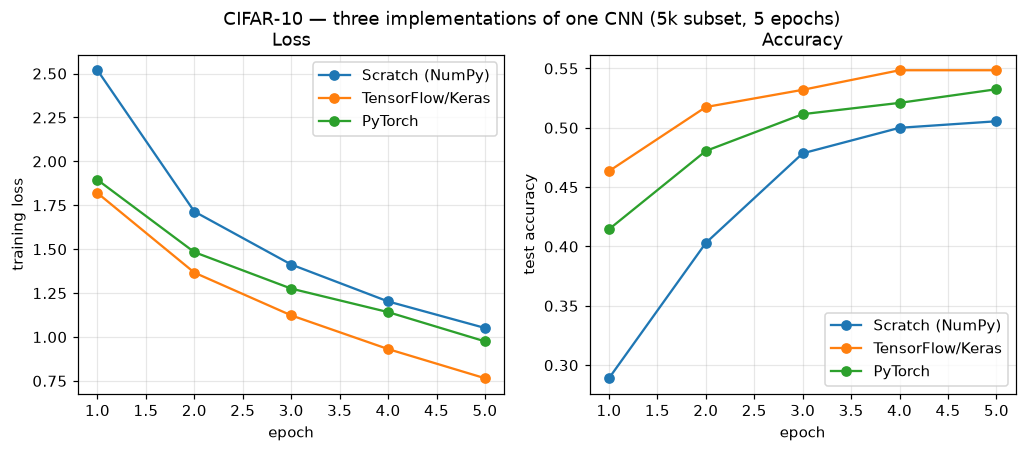

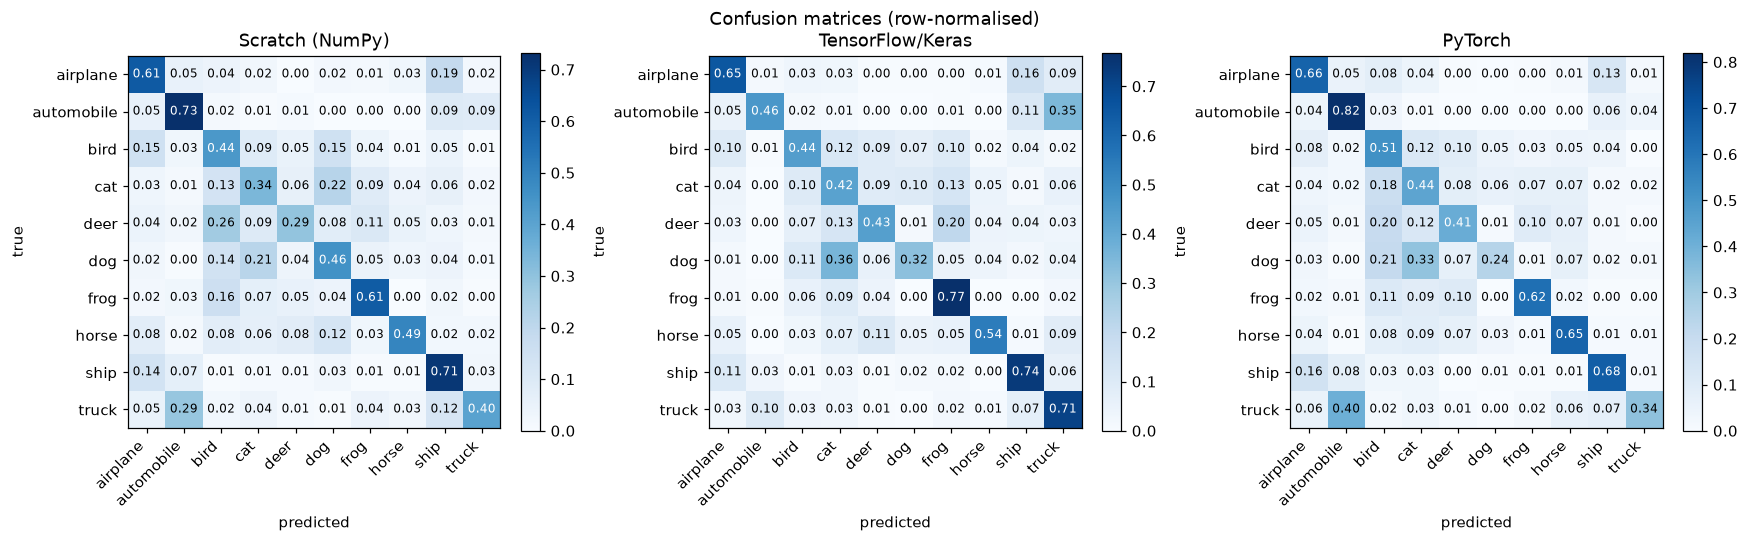

In [17]:
U.plot_history({r.framework: r.history for r in results},
               title="CIFAR-10 — three implementations of one CNN (5k subset, 5 epochs)")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for ax, r in zip(axes, results):
    U.plot_confusion(r.confusion, CLASSES, title=r.framework, ax=ax)
fig.suptitle("Confusion matrices (row-normalised)")
fig.tight_layout()
plt.show()

most confused pairs (true -> predicted), PyTorch run:
  truck        -> automobile   80
  dog          -> cat          72
  dog          -> bird         45
  deer         -> bird         41
  cat          -> bird         39
  ship         -> airplane     31
  airplane     -> ship         27
  deer         -> cat          25

935 wrong out of 2000 (46.8%)


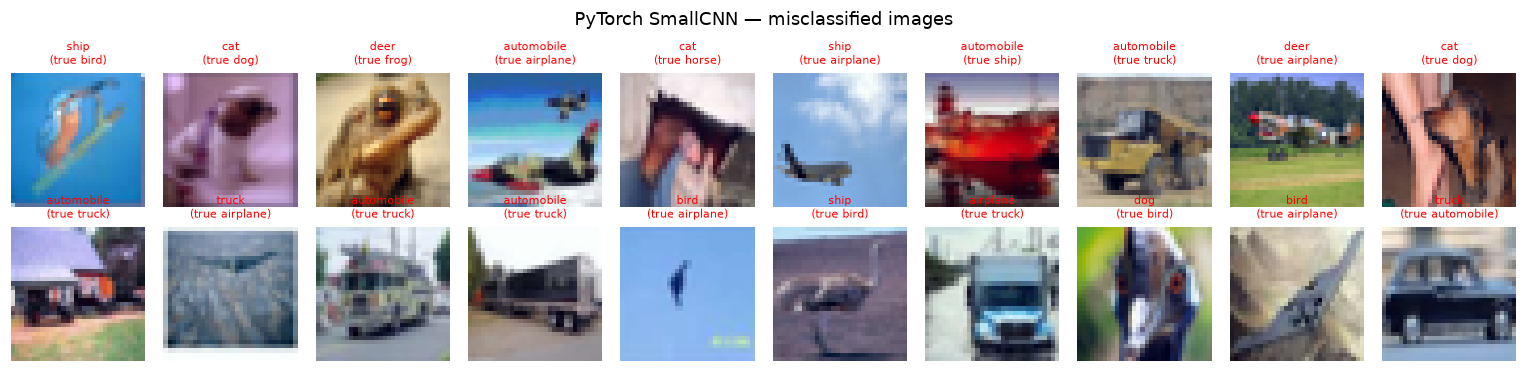

In [18]:
cm = np.array(results[-1].confusion)
np.fill_diagonal(cm, 0)
pairs = np.dstack(np.unravel_index(np.argsort(cm.ravel())[::-1], cm.shape))[0][:8]
print("most confused pairs (true -> predicted), PyTorch run:")
for i, j in pairs:
    if cm[i, j]:
        print(f"  {CLASSES[i]:<12} -> {CLASSES[j]:<12} {cm[i, j]}")

wrong = np.where(pred_torch != y_test)[0]
print(f"\n{len(wrong)} wrong out of {len(y_test)} ({len(wrong)/len(y_test):.1%})")
if len(wrong):
    sel = wrong[:20]
    U.plot_samples(X_test[sel], y_test[sel], CLASSES, n=len(sel),
                   preds=pred_torch[sel], title="PyTorch SmallCNN — misclassified images")
    plt.show()

---
## 7. Chạy tham chiếu trên toàn bộ dữ liệu

Cả hai nhánh framework, huấn luyện lại trên đủ 50.000 ảnh với đúng 5 epoch như trên.

In [19]:
Xtr_f, ytr_f, Xte_f, yte_f, _ = U.load_cifar10(verbose=True)
full_results = []

U.set_seed(U.SEED)
torch_full = SmallCNN(C, N_CLASSES).to(DEVICE)
hist_t_full, secs_t_full = train_torch(torch_full, Xtr_f, ytr_f, Xte_f, yte_f)

torch_full.eval()
with torch.no_grad():
    Xte_ft = torch.tensor(Xte_f).to(DEVICE)
    pred_full_torch = np.concatenate(
        [torch_full(Xte_ft[i:i + 1024]).argmax(1).cpu().numpy()
         for i in range(0, len(Xte_ft), 1024)])

m = U.evaluate(yte_f, pred_full_torch, N_CLASSES)
full_results.append(U.RunResult(
    framework="PyTorch", dataset="CIFAR-10 (full 50k)", model="SmallCNN",
    n_params=n_torch, epochs=EPOCHS, train_seconds=round(secs_t_full, 2),
    train_loss=round(hist_t_full["loss"][-1], 4), history=hist_t_full, **m,
))
print(f"\nPyTorch full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

CIFAR-10: train (50000, 3, 32, 32) / test (10000, 3, 32, 32), 10 classes


epoch 1/5  loss 1.2939  test_acc 0.6355


epoch 2/5  loss 0.9196  test_acc 0.6883


epoch 3/5  loss 0.7602  test_acc 0.7009


epoch 4/5  loss 0.6457  test_acc 0.7103


epoch 5/5  loss 0.5451  test_acc 0.7137

PyTorch full-data: accuracy 0.7137  macro-F1 0.7123


In [20]:
U.set_seed(U.SEED)
keras_full = build_keras_cnn("cifar_cnn_full")
with U.Timer() as t_kf:
    hkf = keras_full.fit(np.transpose(Xtr_f, (0, 2, 3, 1)), ytr_f,
                         validation_data=(np.transpose(Xte_f, (0, 2, 3, 1)), yte_f),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

pred_full_keras = keras_full.predict(np.transpose(Xte_f, (0, 2, 3, 1)),
                                     batch_size=512, verbose=0).argmax(axis=1)
m = U.evaluate(yte_f, pred_full_keras, N_CLASSES)
full_results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="CIFAR-10 (full 50k)", model="SmallCNN",
    n_params=int(keras_full.count_params()), epochs=EPOCHS, train_seconds=round(t_kf.seconds, 2),
    train_loss=round(float(hkf.history["loss"][-1]), 4),
    history={"loss": [float(v) for v in hkf.history["loss"]],
             "val_acc": [float(v) for v in hkf.history["val_accuracy"]]}, **m,
))
print(f"\nKeras full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

Epoch 1/5


782/782 - 15s - 19ms/step - accuracy: 0.5581 - loss: 1.2416 - val_accuracy: 0.6521 - val_loss: 1.0005


Epoch 2/5


782/782 - 14s - 17ms/step - accuracy: 0.6915 - loss: 0.8855 - val_accuracy: 0.6899 - val_loss: 0.9070


Epoch 3/5


...

Epoch 4/5


782/782 - 14s - 18ms/step - accuracy: 0.7873 - loss: 0.6088 - val_accuracy: 0.7049 - val_loss: 0.9355


Epoch 5/5


782/782 - 14s - 17ms/step - accuracy: 0.8262 - loss: 0.5016 - val_accuracy: 0.7043 - val_loss: 0.9806



Keras full-data: accuracy 0.7043  macro-F1 0.6990


In [21]:
display(U.results_table(results + full_results))

sub_best = max(r.test_accuracy for r in results)
full_best = max(r.test_accuracy for r in full_results)
print(f"\nbest on 5k subset : {sub_best:.4f}")
print(f"best on full 50k  : {full_best:.4f}")
print(f"cost of the subset: {full_best - sub_best:+.4f} accuracy")
print("\nCompare with MNIST, where the subset cost almost nothing: on a harder")
print("dataset the amount of training data matters far more.")

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),CIFAR-10 (5k subset),SmallCNN,545098,5,65.23,1.0515,0.5055,0.5216,0.5080,0.5032
1,TensorFlow/Keras,CIFAR-10 (5k subset),SmallCNN,545098,5,9.13,0.7654,0.5485,0.5687,0.5485,0.5452
2,PyTorch,CIFAR-10 (5k subset),SmallCNN,545098,5,2.08,0.9753,0.5325,0.5650,0.5381,0.5288
3,PyTorch,CIFAR-10 (full 50k),SmallCNN,545098,5,17.30,0.5451,0.7137,0.7179,0.7137,0.7123
4,TensorFlow/Keras,CIFAR-10 (full 50k),SmallCNN,545098,5,70.01,0.5016,0.7043,0.7059,0.7043,0.6990



best on 5k subset : 0.5485
best on full 50k  : 0.7137
cost of the subset: +0.1652 accuracy

Compare with MNIST, where the subset cost almost nothing: on a harder
dataset the amount of training data matters far more.


---
## 8. Mỗi thành phần nằm ở đâu

In [22]:
component_table = pd.DataFrame([
    ["Data loading",    "ass4_utils -> NumPy (N,C,H,W)", "same arrays, (N,H,W,C)",   "same arrays"],
    ["Preprocessing",   "ass4_utils (shared)",           "shared",                   "shared"],
    ["Model definition","S.Sequential([...])",           "keras.Sequential([...])",  "nn.Module"],
    ["Convolution",     "S.Conv2D (im2col + matmul)",    "keras.layers.Conv2D",      "nn.Conv2d"],
    ["Activation",      "S.ReLU",                        "activation='relu'",        "nn.ReLU"],
    ["Pooling",         "S.MaxPool2D",                   "keras.layers.MaxPooling2D","nn.MaxPool2d"],
    ["Flatten",         "S.Flatten",                     "keras.layers.Flatten",     "nn.Flatten"],
    ["Dense layer",     "S.Dense",                       "keras.layers.Dense",       "nn.Linear"],
    ["Loss",            "S.SoftmaxCrossEntropy",         "SparseCategoricalCrossentropy", "nn.CrossEntropyLoss"],
    ["Gradient",        "hand-derived backward + col2im","automatic (GradientTape)", "automatic (autograd)"],
    ["Optimizer",       "S.Adam (written out)",          "keras.optimizers.Adam",    "torch.optim.Adam"],
    ["Training loop",   "explicit for-loop",             "model.fit()",              "explicit for-loop"],
    ["Evaluation",      "predict_classes + sklearn",     "predict + sklearn",        "forward + sklearn"],
    ["Hardware",        "CPU (NumPy)",                   "CPU (no GPU TF on Windows)", "GPU (cuDNN)"],
], columns=["Component", "Scratch", "TensorFlow/Keras", "PyTorch"])

display(component_table)

os.makedirs("results", exist_ok=True)
with open("results/03_cifar10.json", "w") as f:
    json.dump({"meta": dict(meta),
               "results": [r.__dict__ for r in results],
               "full_results": [r.__dict__ for r in full_results],
               "component_table": component_table.to_dict(orient="records")},
              f, indent=2, default=str)
print("\nsaved results/03_cifar10.json")

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,"ass4_utils -> NumPy (N,C,H,W)","same arrays, (N,H,W,C)",same arrays
1,Preprocessing,ass4_utils (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module
3,Convolution,S.Conv2D (im2col + matmul),keras.layers.Conv2D,nn.Conv2d
4,Activation,S.ReLU,activation='relu',nn.ReLU
5,Pooling,S.MaxPool2D,keras.layers.MaxPooling2D,nn.MaxPool2d
6,Flatten,S.Flatten,keras.layers.Flatten,nn.Flatten
7,Dense layer,S.Dense,keras.layers.Dense,nn.Linear
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward + col2im,automatic (GradientTape),automatic (autograd)



saved results/03_cifar10.json


## Lưu lại mô hình đã huấn luyện

Tệp JSON ở trên ghi lại các mô hình **đạt** bao nhiêu điểm. Nó không ghi lại các mô hình **là** gì — muốn có
lại những con số này thì phải huấn luyện lại từ đầu.

`U.save_model` ghi từng nhánh theo định dạng gốc của framework tương ứng, vào
`results/models/<notebook>/`, kèm một tệp JSON đi cùng ghi rõ kiến trúc và điểm số mà đúng bộ trọng số đó đạt
được:

| nhánh | tệp | tự nạp lại được? |
|---|---|---|
| Scratch (NumPy) | `.npz`, mỗi tham số của mỗi tầng là một mảng | không |
| TensorFlow/Keras | `.keras`, đồ thị + trọng số | **được** |
| PyTorch | `.pt`, `state_dict` | không |

`.pt` và `.npz` chỉ chứa trọng số, nên nạp lại chúng đồng nghĩa với việc phải dựng lại kiến trúc trước rồi
truyền đối tượng mới vào `U.load_model(..., model=...)`. Đây đúng là giao kèo mà `variants.py` dùng cho
`results/variant_cache/`.

In [23]:
# Weights are the model; metrics only describe it. Persist all three legs.
TAG = "03_cifar10"

by_fw = {r.framework: r for r in results}

for obj, fw, stem in [
    (scratch_model, "Scratch (NumPy)",  "smallcnn_scratch"),
    (keras_model,   "TensorFlow/Keras", "smallcnn_keras"),
    (torch_model,   "PyTorch",          "smallcnn_torch"),
]:
    r = by_fw[fw]
    U.save_model(obj, f"{stem}_subset", TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro)

# The full-data reruns — scratch NumPy is not rerun at this size, so two legs.
by_fw_full = {r.framework: r for r in full_results}

for obj, fw, stem in [
    (keras_full, "TensorFlow/Keras", "smallcnn_keras"),
    (torch_full, "PyTorch",          "smallcnn_torch"),
]:
    r = by_fw_full[fw]
    U.save_model(obj, f"{stem}_full", TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro)

display(U.list_models(TAG)[["name", "framework", "n_params", "dataset", "test_accuracy"]])


saved results\models\03_cifar10\smallcnn_scratch_subset.npz  (545,098 params, 1979 KB)


saved results\models\03_cifar10\smallcnn_keras_subset.keras  (545,098 params, 6425 KB)
saved results\models\03_cifar10\smallcnn_torch_subset.pt  (545,098 params, 2133 KB)
saved results\models\03_cifar10\smallcnn_keras_full.keras  (545,098 params, 6425 KB)
saved results\models\03_cifar10\smallcnn_torch_full.pt  (545,098 params, 2133 KB)


,name,framework,n_params,dataset,test_accuracy
0,smallcnn_keras_full,keras,545098,CIFAR-10 (full 50k),0.7043
1,smallcnn_keras_subset,keras,545098,CIFAR-10 (5k subset),0.5485
2,smallcnn_scratch_subset,scratch,545098,CIFAR-10 (5k subset),0.5055
3,smallcnn_torch_full,torch,545098,CIFAR-10 (full 50k),0.7137
4,smallcnn_torch_subset,torch,545098,CIFAR-10 (5k subset),0.5325


---
## 9. Bộ dữ liệu này cho thấy điều gì

**Ba cách cài đặt vẫn thống nhất.** Vẫn 545.098 tham số, vẫn đúng những kích thước ấy, độ chính xác tương đương
nhau. Qua ba bộ dữ liệu và hai họ mô hình, đổi framework chưa lần nào đổi kết quả — đó chính là luận điểm trung
tâm của bài tập, nay được kiểm chứng chứ không chỉ được phát biểu.

**Nhưng ở đây bản thân mô hình rõ ràng là chưa đủ sức.** Chỗ MNIST gần bão hoà thì CNN nhỏ này còn cách rất xa
trên CIFAR-10, và ma trận nhầm lẫn cho biết vì sao: mèo/chó, nai/ngựa, ô tô con/xe tải. Đây là những lớp cần
kết cấu và cấu trúc bộ phận, không chỉ cần cạnh. Năm epoch với chồng hai tầng tích chập không cung cấp nổi điều
đó.

**Và tham số nằm sai chỗ.** 96 % mô hình dồn vào bước `Flatten → Linear(4096→128)`, trong khi các tầng tích
chập thực sự trích xuất đặc trưng chỉ giữ chưa tới 20.000 tham số. Tăng sức chứa bằng cách nới rộng tầng dày
đặc ấy sẽ là cách tiêu tham số **tệ nhất** — nó chỉ nhìn thấy các kích hoạt đã qua gộp và không còn cấu trúc
không gian nào để khai thác.

Chẩn đoán đó là cây cầu dẫn sang notebook cuối. Mục §45 của tài liệu yêu cầu đúng thí nghiệm mà tình huống này
đòi hỏi:

$$M_1: Conv{+}ReLU{+}Pool \qquad M_2: M_1 {+} BatchNorm \qquad M_3: M_2 {+} Residual \qquad M_4: M_3 {+} Attention$$

Mỗi mô hình là kiến trúc trước đó cộng thêm đúng một cơ chế xử lý một hạn chế cụ thể — đúng công thức của tài
liệu: "kiến trúc mới = kiến trúc cũ + một cơ chế xử lý một hạn chế". CIFAR-10 đủ khó để những khác biệt ấy lộ
ra thành con số.

Tiếp theo: **`04_compare.ipynb`**.